In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
  0% 0.00/149M [00:00<?, ?B/s]
100% 149M/149M [00:00<00:00, 1.64GB/s]


In [ ]:
import zipfile
import os

zip_path = '/content/dataset/brain-tumor-mri-dataset.zip'
extract_path = '/content/extracted'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzipping completed!")
else:
    print(f"File not found: {zip_path}")

Unzipping completed!


**EfficientNetB3 model**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# Sklearn for splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3  # Changed from Xception

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. DATA PREPARATION
# ==========================================

# Function to create dataframe from Training folder
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])
    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

# Function to create dataframe from Testing folder
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])
    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

# Load the data (Ensure these paths exist in your environment)
# NOTE: If you are running this locally, change these paths to your actual data location
tr_df = train_df('/content/extracted/Training')
ts_df = test_df('/content/extracted/Testing')

# Split Testing dataframe into Validation and Test sets (50% each)
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

# Display class counts (Optional visualization)
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])
plt.title('Count of images in each class (Train)', fontsize=20)
plt.show()

# ==========================================
# 2. DATA GENERATORS (MODIFIED FOR EFFICIENTNET)
# ==========================================

# EfficientNetB3 expects (300, 300) for best results
img_size = (300, 300)
batch_size = 16 # Adjust based on your GPU VRAM (16 or 32)

# IMPORTANT: EfficientNet expects [0-255] range. Do NOT use rescale=1/255.
_gen = ImageDataGenerator(
    # rescale=1/255,
    brightness_range=(0.8, 1.2), # Simple augmentation
    horizontal_flip=True,        # Added extra augmentation
    zoom_range=0.1
)

ts_gen = ImageDataGenerator(
    # rescale=1/255
)

# Create Flow from Dataframes
tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size, shuffle=False)

# ==========================================
# 3. MODEL DEFINITION (EFFICIENTNETB3)
# ==========================================

# Load base model
base_model = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3),
    pooling='max' # GlobalMaxPooling reduces dimensions directly
)

# Freeze base model layers so we don't destroy pretrained weights immediately
base_model.trainable = False

model = Sequential([
    base_model,
    # Optional: BatchNormalization could be added here
    Dense(256, activation='relu'),
    Dropout(0.4), # Increased dropout slightly to prevent overfitting
    Dense(4, activation='softmax') # 4 Classes: glioma, meningioma, notumor, pituitary
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

model.summary()

# ==========================================
# 4. TRAINING
# ==========================================

# Define callbacks (Optional but recommended)
# Stops training if validation loss doesn't improve for 3 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

epochs = 30 # You can increase this

history = model.fit(
    tr_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=[early_stopping]
)

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================

# Plot Training History
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

# Evaluate on Test Data
print("\nEvaluating on Test Set...")
test_loss, test_acc, test_prec, test_rec = model.evaluate(ts_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Confusion Matrix
y_pred = model.predict(ts_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
true_classes = ts_gen.classes
class_labels = list(ts_gen.class_indices.keys())

cm = confusion_matrix(true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(true_classes, y_pred_classes, target_names=class_labels))

In [ ]:
model.save('Model1.keras')

**EfficientNetB3 model**

In [ ]:
import zipfile
import os

zip_path = '/content/dataset/brain-tumor-mri-dataset.zip'
extract_path = '/content/extracted'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzipping completed!")
else:
    print(f"File not found: {zip_path}")

Unzipping completed!


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# Sklearn for splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3  # Changed from Xception

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. DATA PREPARATION
# ==========================================

# Function to create dataframe from Training folder
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])
    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

# Function to create dataframe from Testing folder
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])
    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

# Load the data (Ensure these paths exist in your environment)
# NOTE: If you are running this locally, change these paths to your actual data location
tr_df = train_df('/content/extracted/Training')
ts_df = test_df('/content/extracted/Testing')

# Split Testing dataframe into Validation and Test sets (50% each)
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

# Display class counts (Optional visualization)
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])
plt.title('Count of images in each class (Train)', fontsize=20)
plt.show()

# ==========================================
# 2. DATA GENERATORS (MODIFIED FOR EFFICIENTNET)
# ==========================================

# EfficientNetB3 expects (300, 300) for best results
img_size = (300, 300)
batch_size = 16 # Adjust based on your GPU VRAM (16 or 32)

# IMPORTANT: EfficientNet expects [0-255] range. Do NOT use rescale=1/255.
_gen = ImageDataGenerator(
    # rescale=1/255,             <-- REMOVED for EfficientNet
    brightness_range=(0.8, 1.2), # Simple augmentation
    horizontal_flip=True,        # Added extra augmentation
    zoom_range=0.1
)

ts_gen = ImageDataGenerator(
    # rescale=1/255              <-- REMOVED for EfficientNet
)

# Create Flow from Dataframes
tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size, shuffle=False)

# ==========================================
# 3. MODEL DEFINITION (EFFICIENTNETB3)
# ==========================================

# Load base model
base_model = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(300, 300, 3),
    pooling='max' # GlobalMaxPooling reduces dimensions directly
)

# Freeze base model layers so we don't destroy pretrained weights immediately
base_model.trainable = False

model = Sequential([
    base_model,
    # Optional: BatchNormalization could be added here
    Dense(256, activation='relu'),
    Dropout(0.4), # Increased dropout slightly to prevent overfitting
    Dense(4, activation='softmax') # 4 Classes: glioma, meningioma, notumor, pituitary
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

model.summary()

# ==========================================
# 4. TRAINING
# ==========================================

# Define callbacks (Optional but recommended)
# Stops training if validation loss doesn't improve for 3 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

epochs = 10 # You can increase this

history = model.fit(
    tr_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=[early_stopping]
)

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================

# Plot Training History
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

# Evaluate on Test Data
print("\nEvaluating on Test Set...")
test_loss, test_acc, test_prec, test_rec = model.evaluate(ts_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Confusion Matrix
y_pred = model.predict(ts_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
true_classes = ts_gen.classes
class_labels = list(ts_gen.class_indices.keys())

cm = confusion_matrix(true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(true_classes, y_pred_classes, target_names=class_labels))

**xception model**

**Improt the lib**

In [ ]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

2. Preprocessing
2.1 Load data

In [ ]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [ ]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [ ]:


tr_df = train_df('/content/extracted/Training')



In [ ]:
tr_df

,Class Path,Class
0,/content/extracted/Training/meningioma/Tr-me_0...,meningioma
1,/content/extracted/Training/meningioma/Tr-me_0...,meningioma
2,/content/extracted/Training/meningioma/Tr-me_0...,meningioma
3,/content/extracted/Training/meningioma/Tr-me_0...,meningioma
4,/content/extracted/Training/meningioma/Tr-me_0...,meningioma
...,...,...
5707,/content/extracted/Training/notumor/Tr-no_0402...,notumor
5708,/content/extracted/Training/notumor/Tr-no_0746...,notumor
5709,/content/extracted/Training/notumor/Tr-no_1196...,notumor
5710,/content/extracted/Training/notumor/Tr-no_1444...,notumor


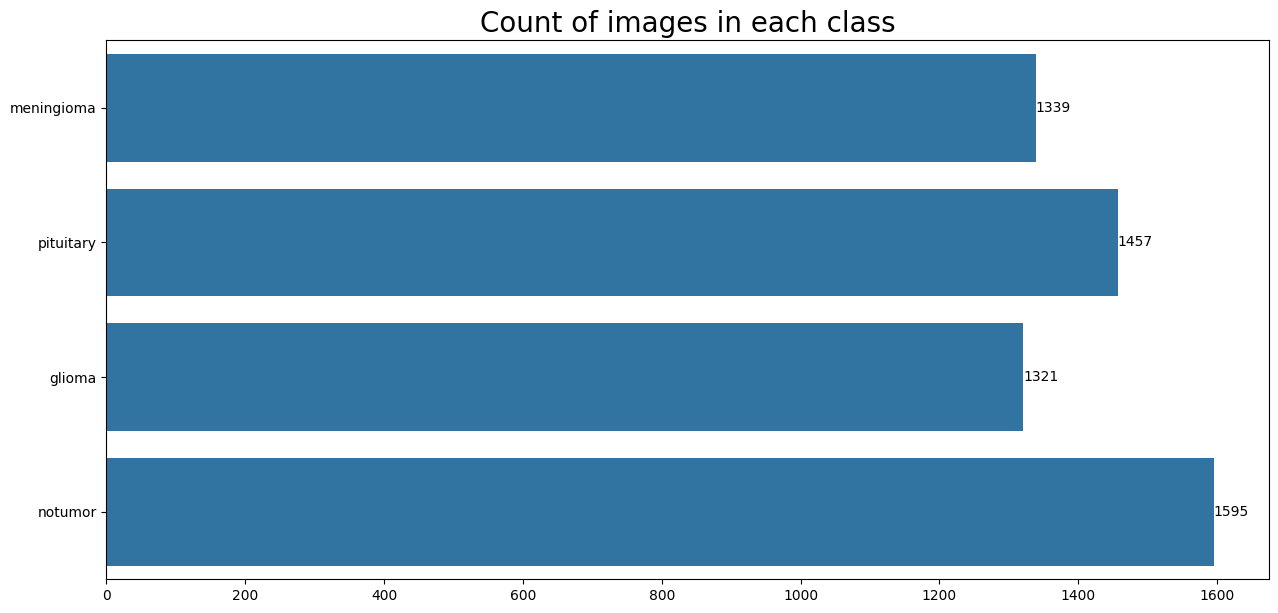

In [ ]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

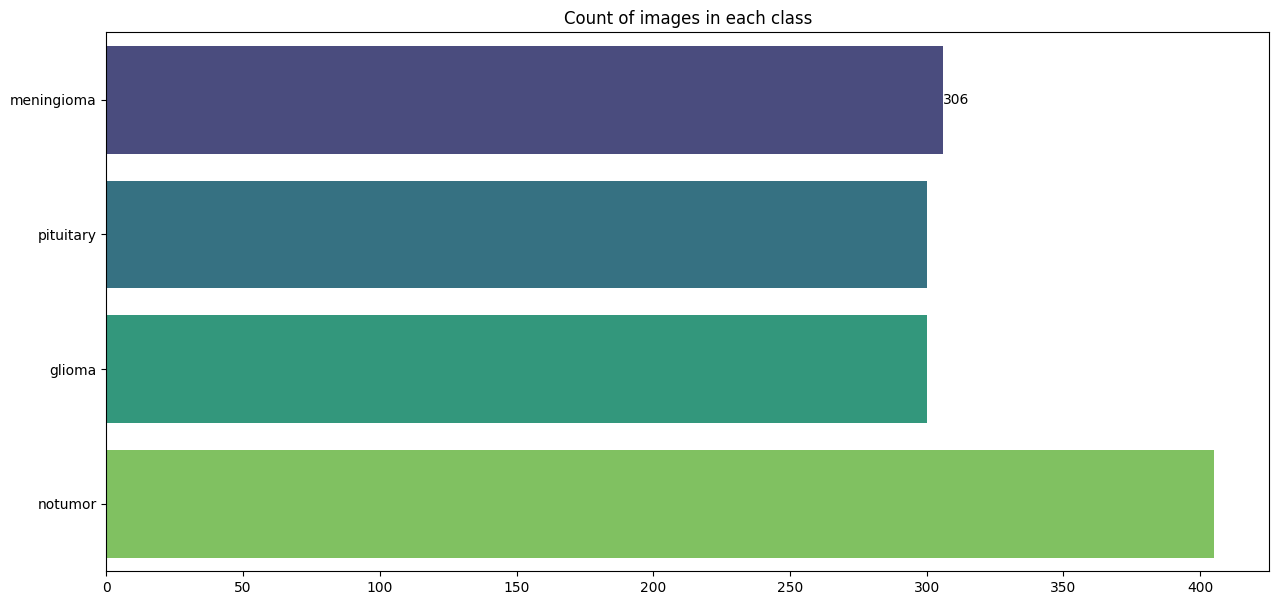

In [ ]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()


2.2 Split data into train, test, valid¶


In [ ]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [ ]:
valid_df

,Class Path,Class
892,/content/extracted/Testing/glioma/Te-gl_0044.jpg,glioma
18,/content/extracted/Testing/meningioma/Te-me_01...,meningioma
367,/content/extracted/Testing/pituitary/Te-pi_021...,pituitary
73,/content/extracted/Testing/meningioma/Te-me_02...,meningioma
715,/content/extracted/Testing/glioma/Te-gl_0206.jpg,glioma
...,...,...
665,/content/extracted/Testing/glioma/Te-gl_0239.jpg,glioma
1160,/content/extracted/Testing/notumor/Te-no_0397.jpg,notumor
879,/content/extracted/Testing/glioma/Te-gl_0245.jpg,glioma
194,/content/extracted/Testing/meningioma/Te-me_02...,meningioma



2.3 Data preprocessing¶


In [ ]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.



2.4 Getting samples from data


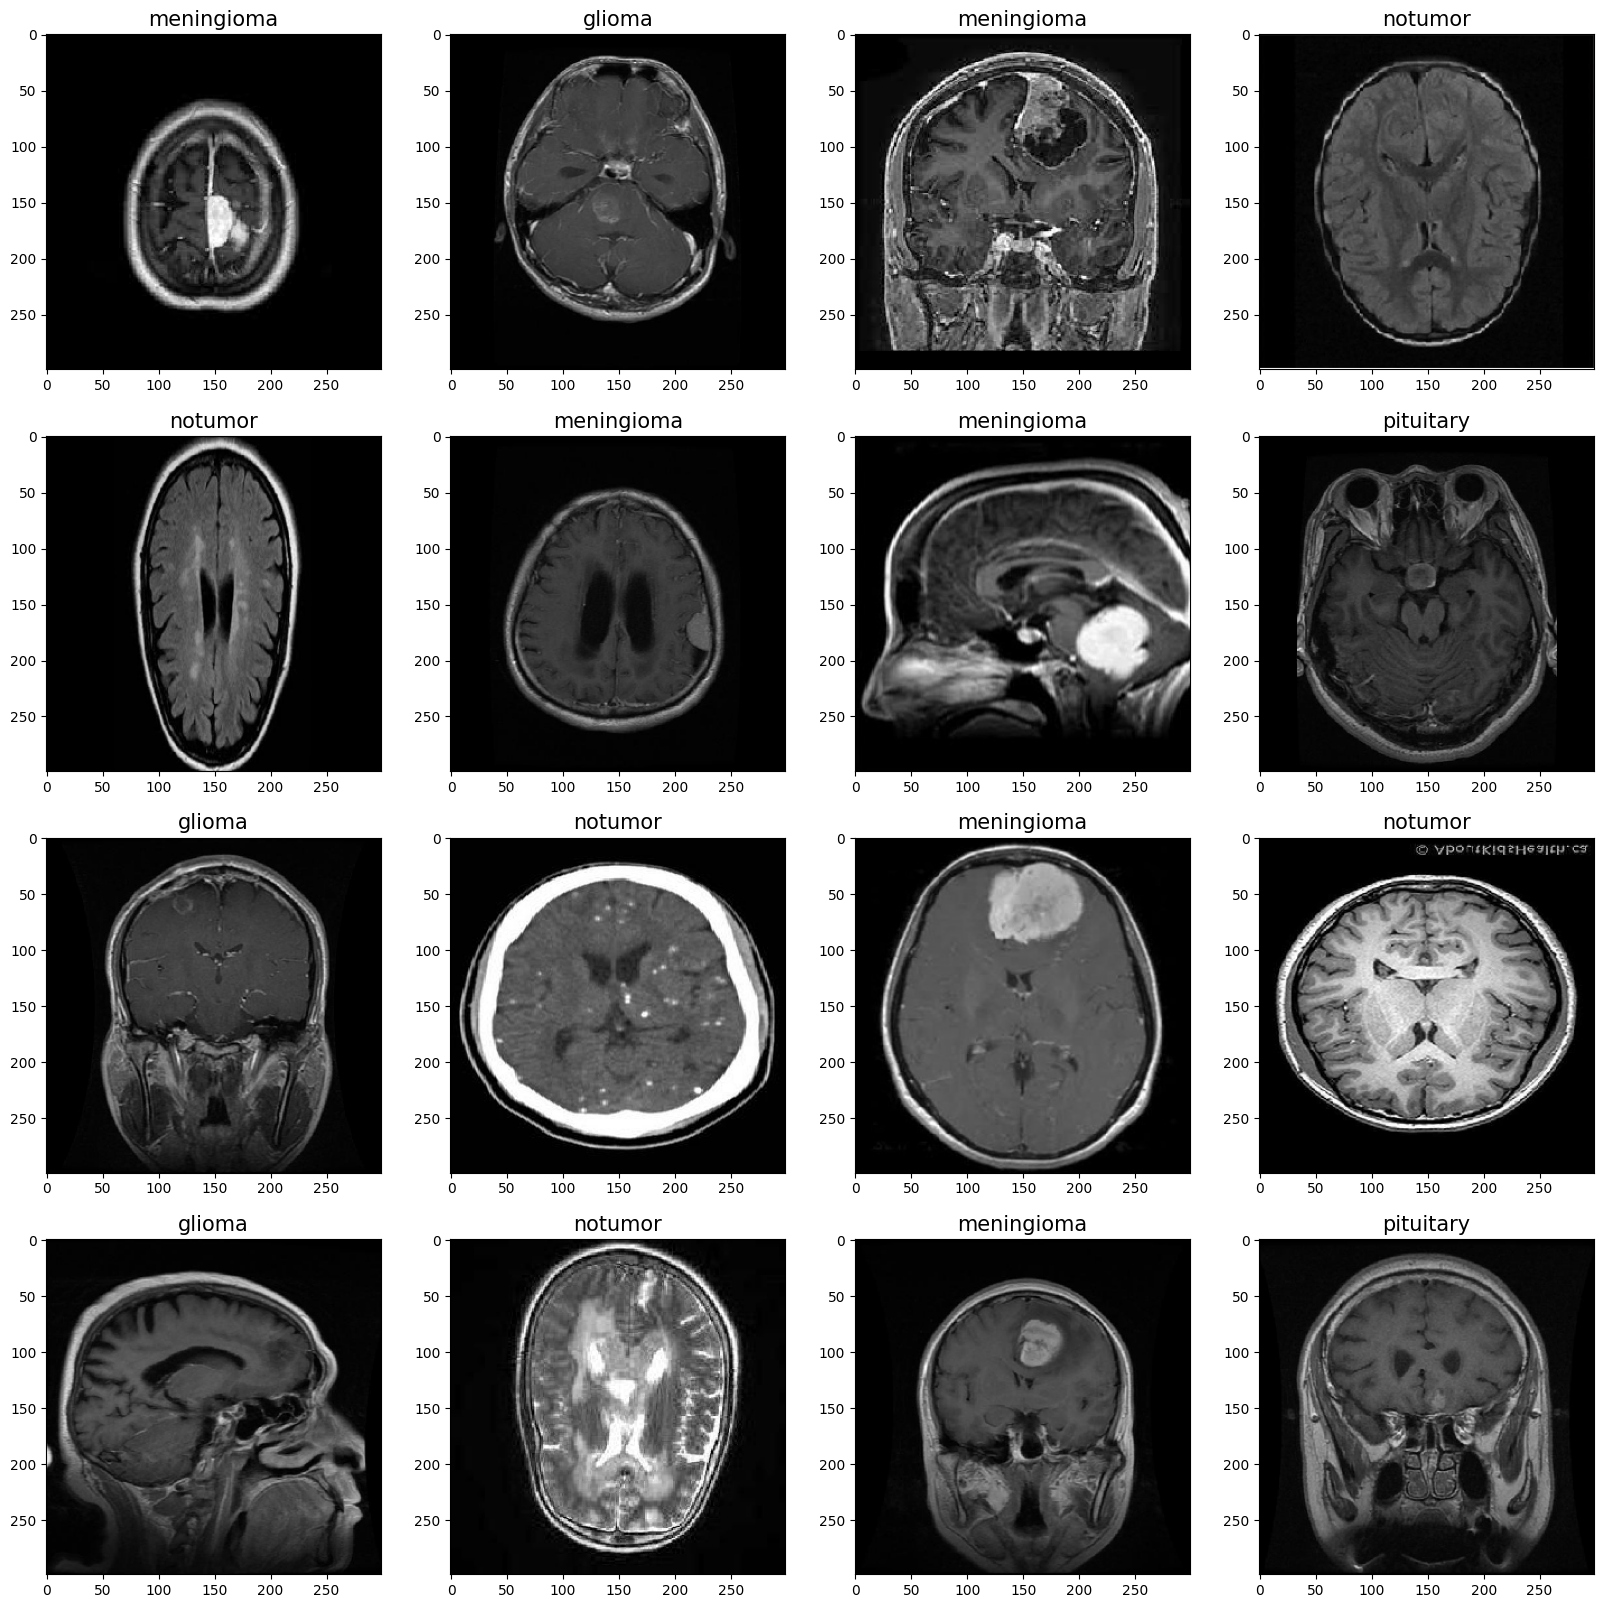

In [ ]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()


3. Building Deep Learning Model


In [ ]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

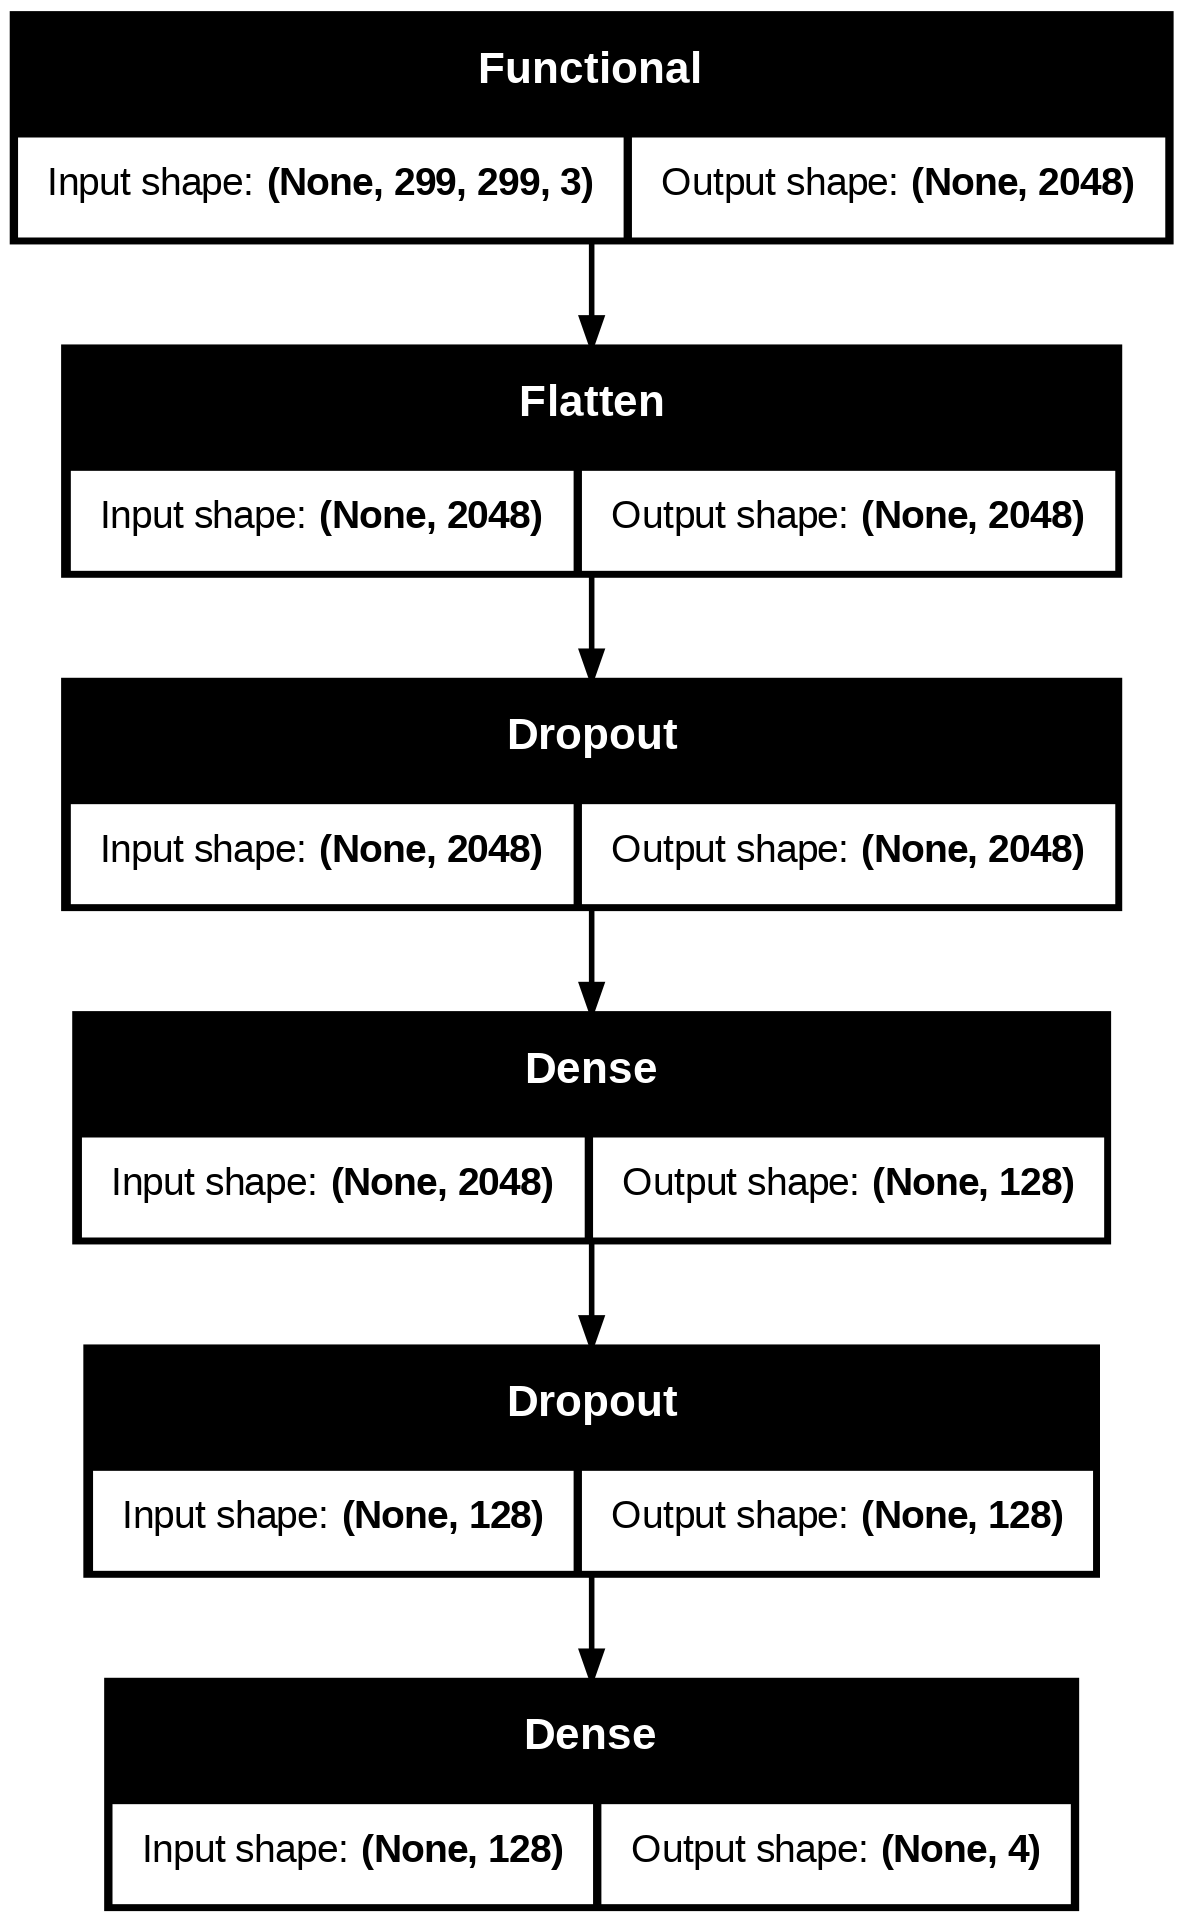

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)


4. Training


In [ ]:
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.8252 - loss: 0.6175 - precision: 0.8528 - recall: 0.7401 - val_accuracy: 0.8885 - val_loss: 0.3819 - val_precision: 0.8935 - val_recall: 0.8840
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 161s 898ms/step - accuracy: 0.9821 - loss: 0.0612 - precision: 0.9830 - recall: 0.9802 - val_accuracy: 0.9725 - val_loss: 0.1037 - val_precision: 0.9754 - val_recall: 0.9679
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 160s 894ms/step - accuracy: 0.9938 - loss: 0.0222 - precision: 0.9948 - recall: 0.9922 - val_accuracy: 0.9710 - val_loss: 0.0888 - val_precision: 0.9709 - val_recall: 0.9664
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 160s 894ms/step - accuracy: 0.9925 - loss: 0.0221 - precision: 0.9928 - recall: 0.9915 - val_accuracy: 0.9832 - val_loss: 0.0516 - val_precision: 0.9832 - val_recall: 0.9832
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 160s 894ms/step - accuracy: 0.9962 - loss: 0.0122 - precision: 0.9969 - recall: 0.9962 - val_accuracy: 0.96

In [ ]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


4.1 Visualize model performance

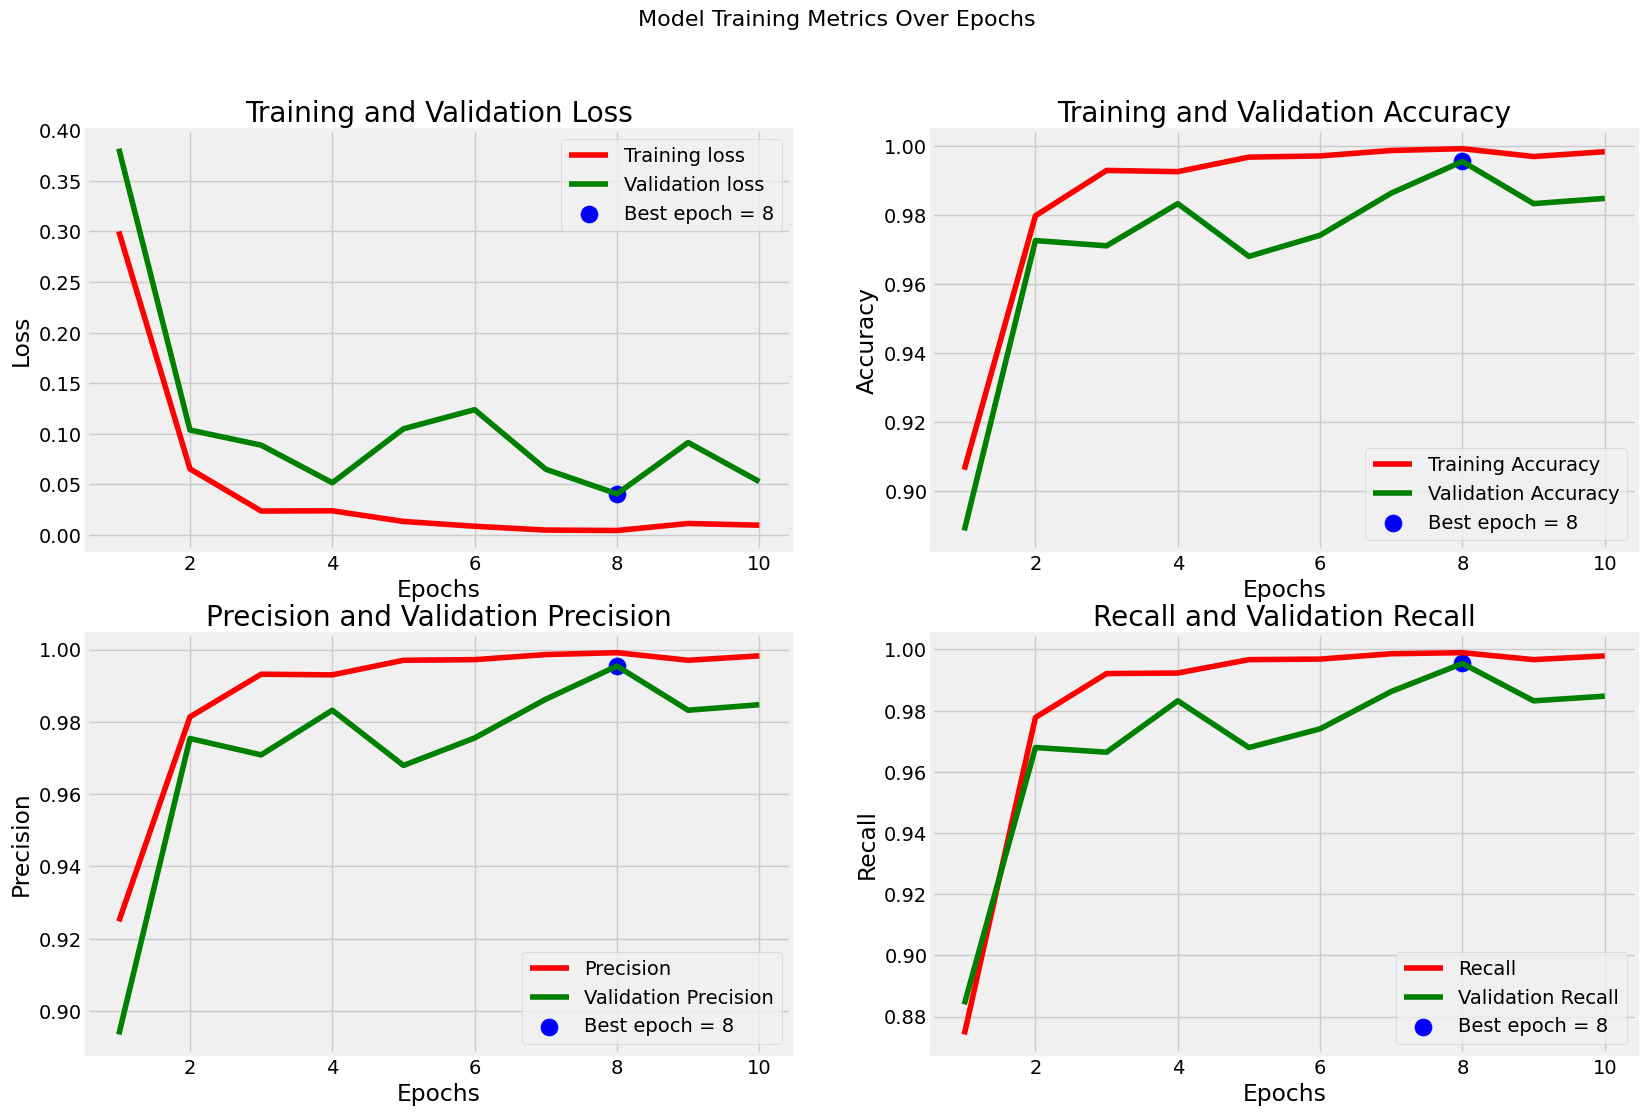

In [ ]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()


5. Testing and Evaluation¶


In [ ]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

179/179 ━━━━━━━━━━━━━━━━━━━━ 55s 308ms/step - accuracy: 1.0000 - loss: 3.5895e-04 - precision: 1.0000 - recall: 1.0000
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.9814 - loss: 0.0504 - precision: 0.9814 - recall: 0.9814
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9969 - loss: 0.0185 - precision: 0.9969 - recall: 0.9969
Train Loss: 0.0003
Train Accuracy: 100.00%
--------------------
Validation Loss: 0.0479
Validation Accuracy: 98.47%
--------------------
Test Loss: 0.0331
Test Accuracy: 99.24%


In [ ]:
preds_model2 = model.predict(ts_gen)
y_pred_model2 = np.argmax(preds_model2, axis=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step


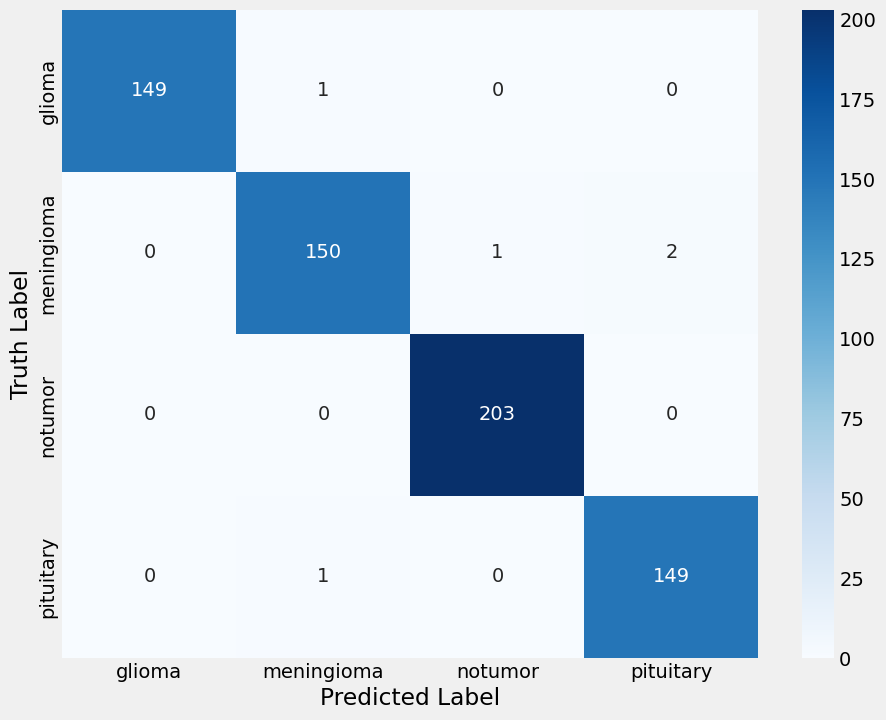

In [ ]:
cm = confusion_matrix(ts_gen.classes, y_pred_model2)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [ ]:
clr = classification_report(ts_gen.classes, y_pred_model2, digits=4)
print(clr)

              precision    recall  f1-score   support

           0     1.0000    0.9933    0.9967       150
           1     0.9868    0.9804    0.9836       153
           2     0.9951    1.0000    0.9975       203
           3     0.9868    0.9933    0.9900       150

    accuracy                         0.9924       656
   macro avg     0.9922    0.9918    0.9920       656
weighted avg     0.9924    0.9924    0.9924       656



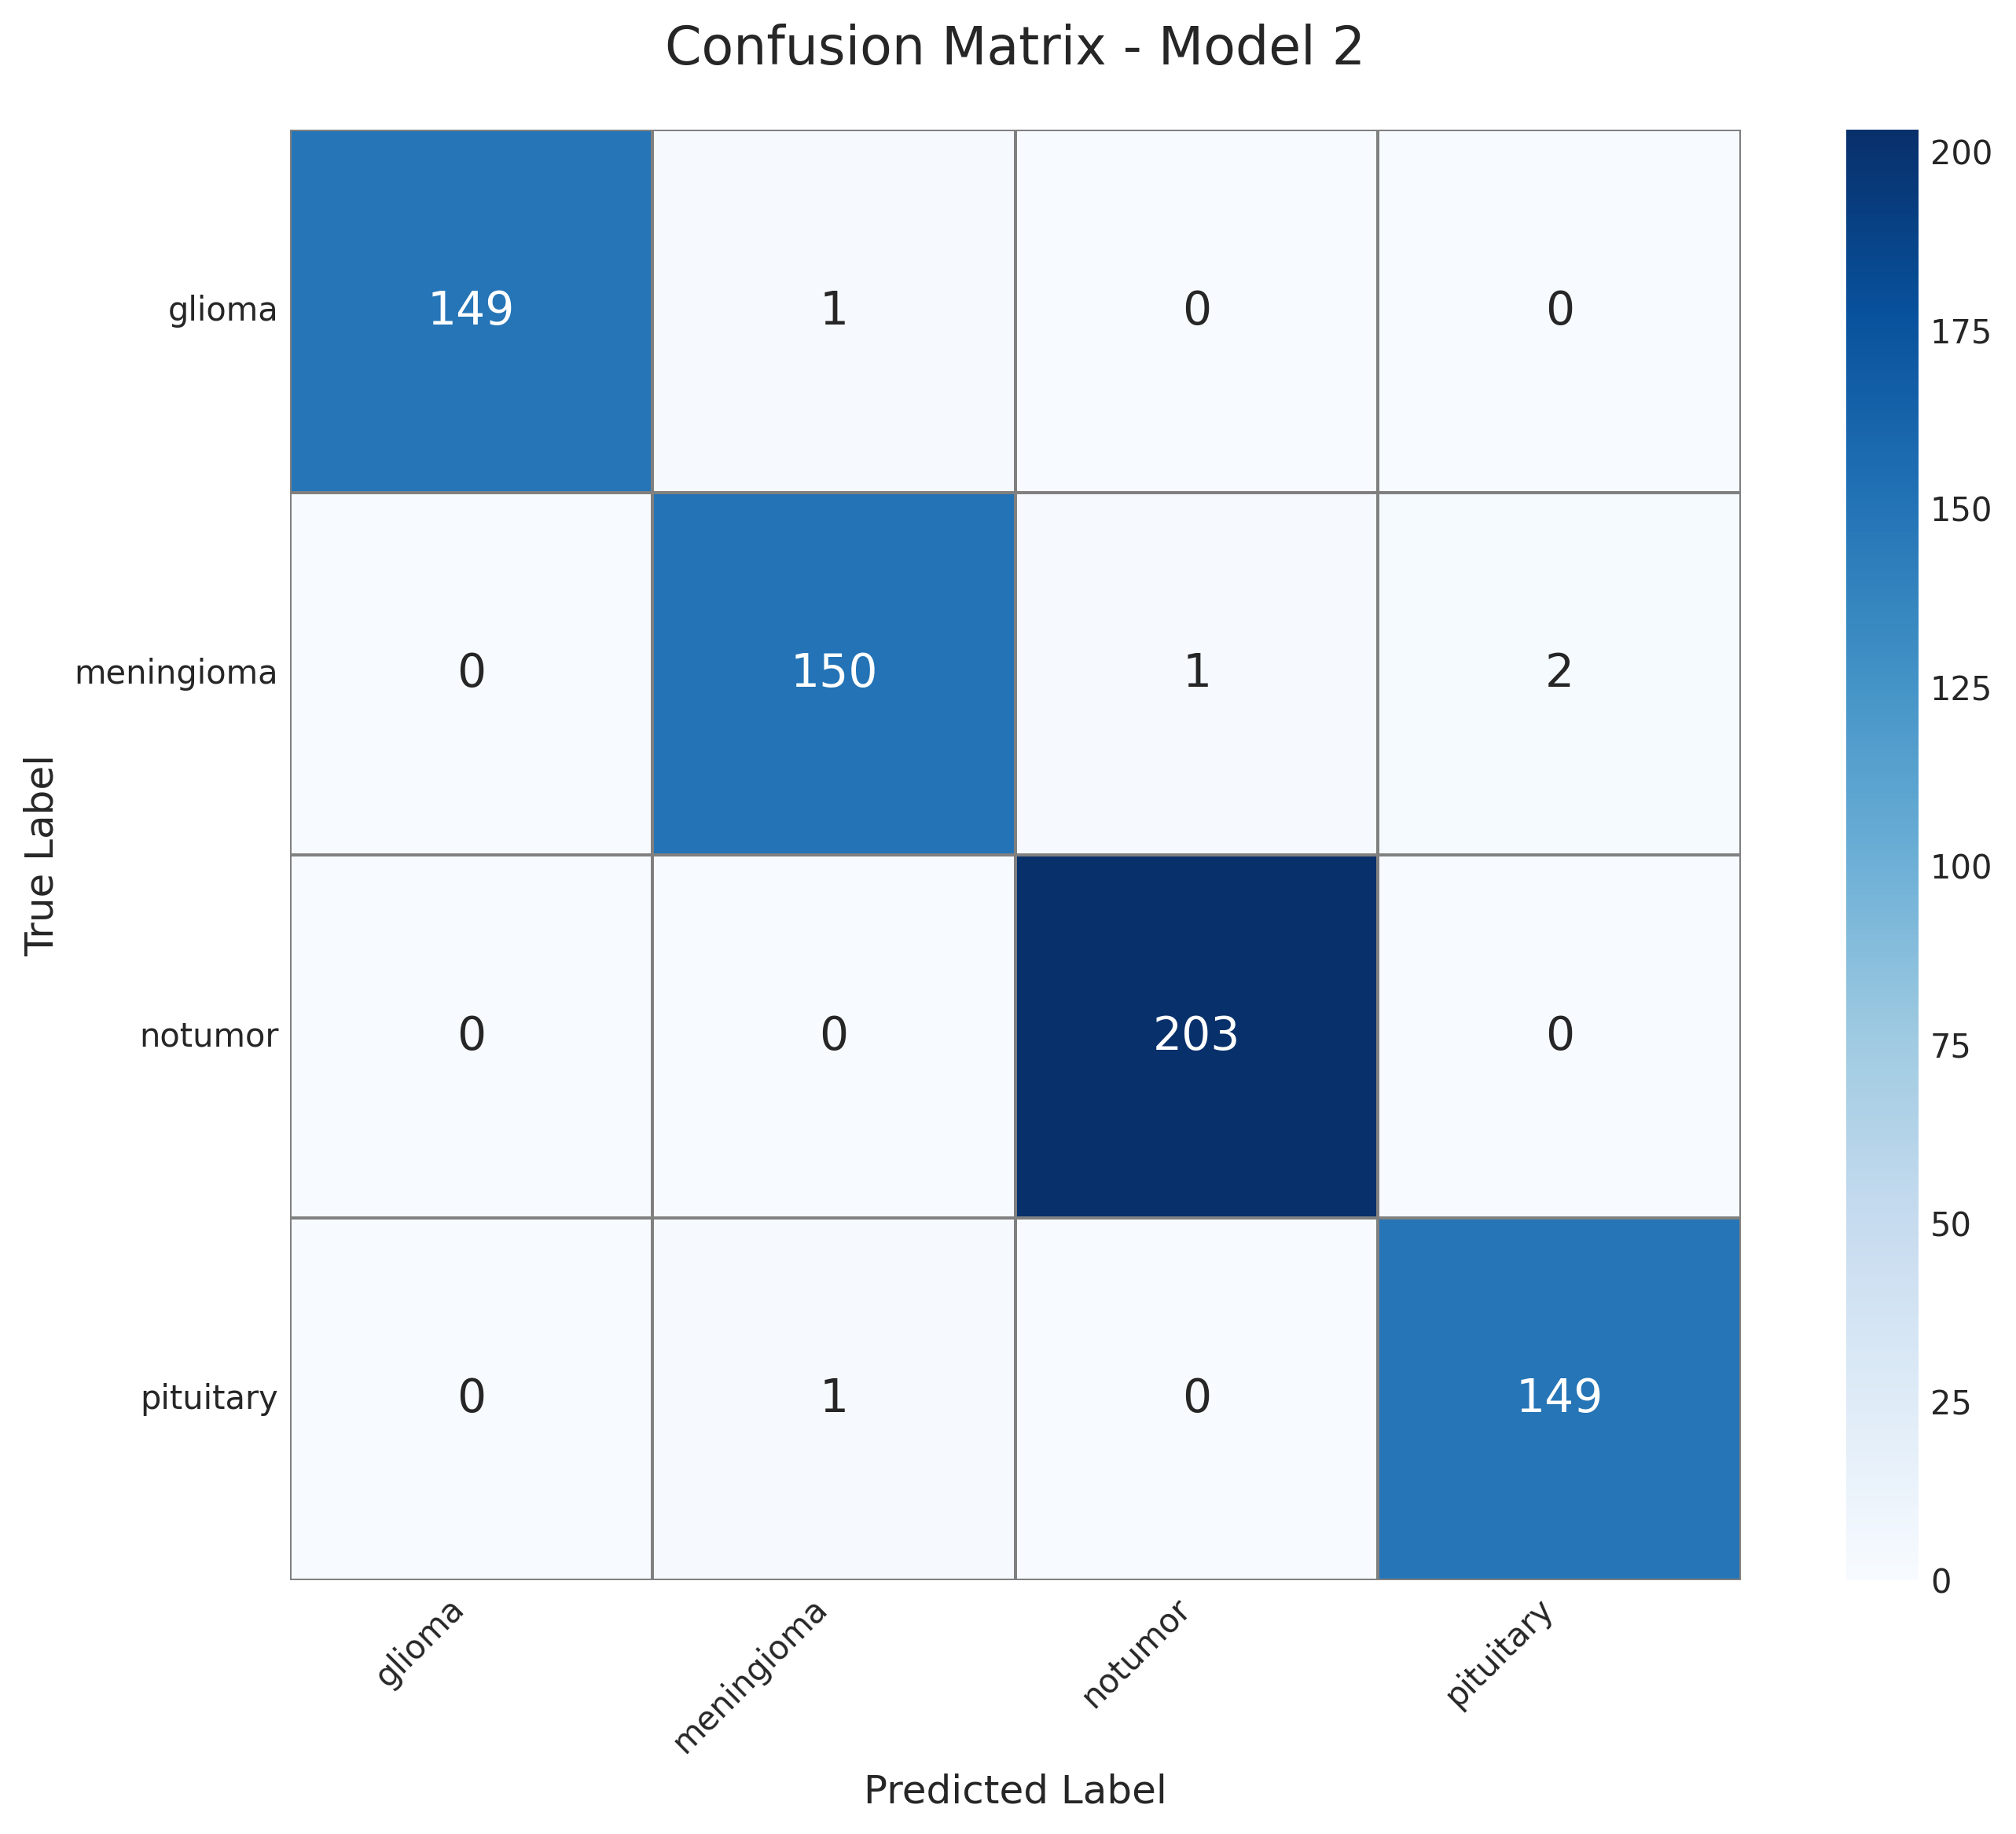

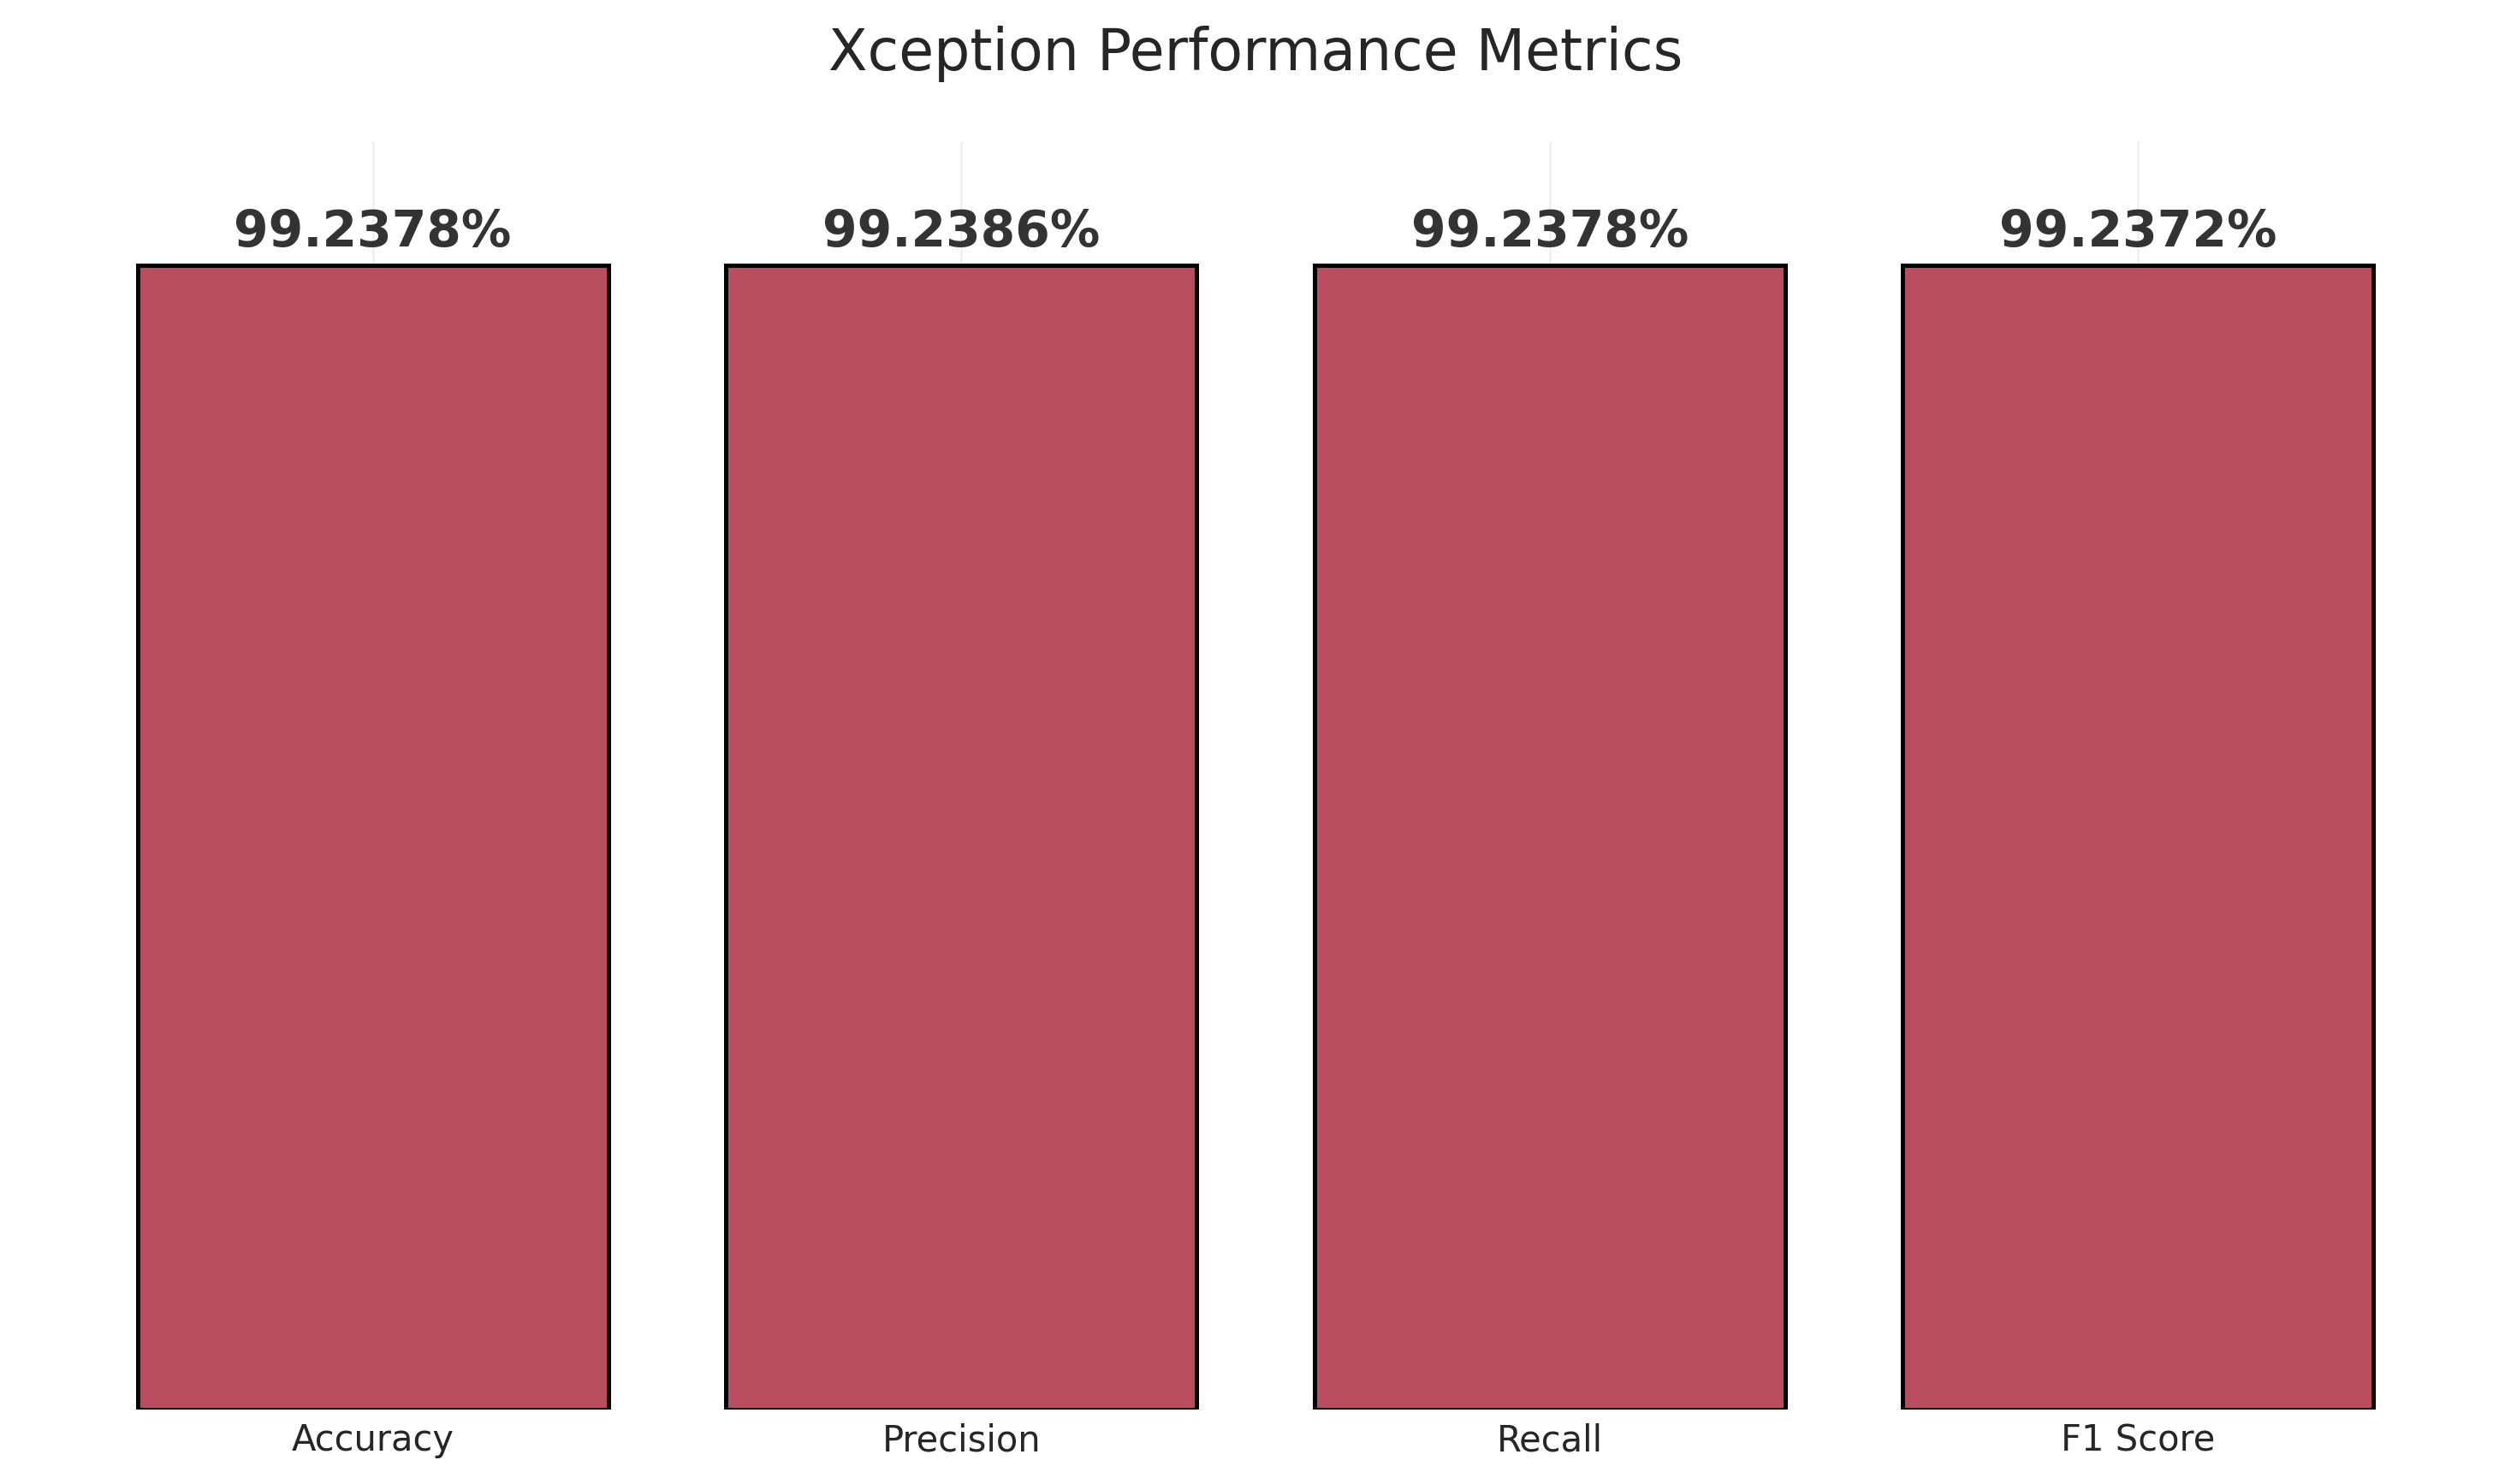


=== Model 2 - Detailed Classification Report ===


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

# ================================================================
# Assuming you already have these variables for the SECOND model:
#   ts_gen    → your test generator (has .classes and .class_indices)
#   y_pred_model2    → predicted class indices (numpy array or list)
#   class_dict → dictionary like {'COVID':0, 'Normal':1, ...}
# ================================================================

# ------------------------------------------------------------------
# 1. Class names
# ------------------------------------------------------------------
labels = list(class_dict.keys())          # e.g. ['COVID', 'Normal', 'Pneumonia']
n_classes = len(labels)

# ------------------------------------------------------------------
# 2. Confusion Matrix (nice looking, same style as first model)
# ------------------------------------------------------------------
cm = confusion_matrix(ts_gen.classes, y_pred_model2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=True, linewidths=0.5, linecolor='gray',
            square=True)
plt.title('Confusion Matrix - Model 2', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3. Classification Report as Bar Chart (EXACTLY like your image)
# ------------------------------------------------------------------
accuracy  = accuracy_score(ts_gen.classes, y_pred_model2)
precision = precision_score(ts_gen.classes, y_pred_model2, average='weighted', zero_division=0)
recall    = recall_score(ts_gen.classes, y_pred_model2, average='weighted', zero_division=0)
f1        = f1_score(ts_gen.classes, y_pred_model2, average='weighted', zero_division=0)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [accuracy, precision, recall, f1]
percentages = [f"{v:.4%}" for v in values]   # e.g. "99.14%"

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color='#b84d5f',   # same red as your picture
                edgecolor='black', linewidth=1.2)

# Put the percentage number on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.008,
             percentages[i],
             ha='center', va='bottom', fontsize=14, fontweight='bold', color='#333')

# Exact styling to match your original image
plt.ylim(0, 1.1)
plt.title('Xception Performance Metrics', fontsize=16, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True, bottom=True)

# Hide y-axis ticks (we show values on top)
plt.gca().set_yticks([])
plt.gca().set_yticklabels([])

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# (Optional) Print full classification report in console
# ------------------------------------------------------------------
print("\n=== Model 2 - Detailed Classification Report ===")
report = classification_report(ts_gen.classes, y_pred_model2,
                               target_names=labels, digits=4)

In [ ]:
model.save('Model2.keras')